In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
DATA_DIR = Path("../data/raw")

In [4]:
FIGURES_DIR = Path("../results/figures")

# Patients Data File

In [5]:
patients = pd.read_csv(DATA_DIR/"hosp"/"patients.csv")

In [6]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [7]:
patients.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject_id,100.00,NaN,NaN,NaN,10018776.86,11151.15,10000032.00,10008889.75,10019087.50,10025500.25,10040025.00
gender,100,2,M,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anchor_age,100.00,NaN,NaN,NaN,61.75,16.17,21.00,51.75,63.00,72.00,91.00
anchor_year,100.00,NaN,NaN,NaN,2148.68,25.63,2110.00,2129.00,2145.50,2172.50,2201.00
anchor_year_group,100,2,2014 - 2016,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dod,31,31,2137-09-02,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Checking for null values
patients.isna().sum()

subject_id            0
gender                0
anchor_age            0
anchor_year           0
anchor_year_group     0
dod                  69
dtype: int64

### Observation:

* The `dod` variable contains **69 missing values**, meaning that 31 of the 100 patients have a recorded date of death.
* This should not be interpreted as 31 in-hospital deaths. The `dod` field may capture deaths recorded from both hospital and state death records, including deaths occurring after hospital discharge.


### Patient age distribution

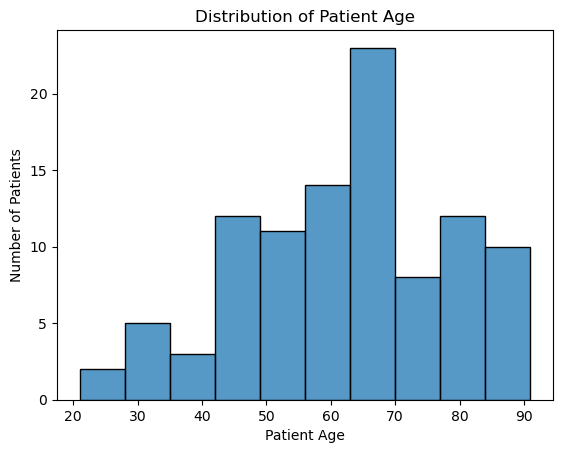

In [9]:
ax = sns.histplot(
    data=patients,
    x='anchor_age',
    bins=10
)

plt.xlabel('Patient Age')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patient Age')

# Save the chart
plt.savefig(
    FIGURES_DIR / "patient_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Gender Distribution

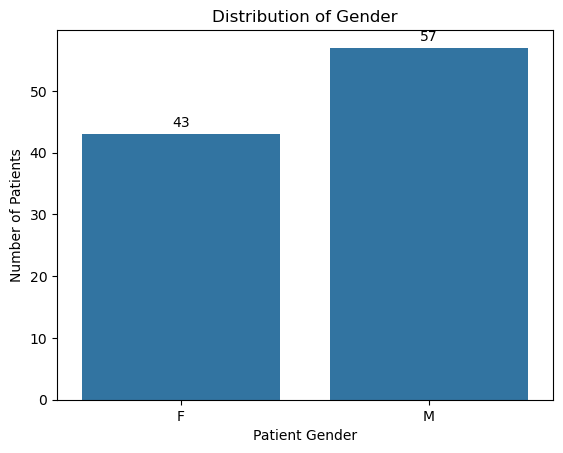

In [10]:
ax = sns.countplot(
    data=patients,
    x='gender'
)

plt.xlabel('Patient Gender')
plt.ylabel('Number of Patients')
plt.title('Distribution of Gender')

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


plt.show()

# ICU Stays

In [11]:
icu_stays = pd.read_csv(DATA_DIR/"icu"/"icustays.csv")

### Detailed Description

- `subject_id, hadm_id, stay_id`
Identifiers which specify the patient: subject_id is unique to a patient, hadm_id is unique to a patient hospital stay and stay_id is unique to a patient ward stay.

- `FIRST_CAREUNIT, LAST_CAREUNIT`
FIRST_CAREUNIT and LAST_CAREUNIT contain, respectively, the first and last ICU type in which the patient was cared for. As an stay_id groups all ICU admissions within 24 hours of each other, it is possible for a patient to be transferred from one type of ICU to another and have the same stay_id.

- `Care units` are derived from the TRANSFERS table, and the definition for the abbreviations can be found in the documentation for TRANSFERS.

- `INTIME, OUTTIME`
INTIME provides the date and time the patient was transferred into the ICU. OUTTIME provides the date and time the patient was transferred out of the ICU.

- `LOS`
LOS is the length of stay for the patient for the given ICU stay, which may include one or more ICU units. The length of stay is measured in fractional days.


In [12]:
icu_stays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.70
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.45
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.87
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.77
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.04


### Observation:
- The years in the INTIME AND OUTTIME date time columns are not valid years.

In [13]:
icu_stays.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los'],
      dtype='object')

In [14]:
icu_stays.describe().T

,count,mean,std,min,25%,50%,75%,max
subject_id,140.00,10018563.32,10857.82,10000032.00,10009045.50,10019003.00,10023839.00,10040025.00
hadm_id,140.00,25150128.46,2929135.34,20044587.00,22724798.00,24837052.00,27907581.50,29974575.00
stay_id,140.00,35102545.21,2823925.23,30057454.00,32503635.00,35137515.50,37300933.25,39880770.00
los,140.00,3.68,3.90,0.02,1.17,2.16,4.91,20.53


In [15]:
icu_stays.shape

(140, 8)

In [16]:
icu_stays.nunique()

subject_id        100
hadm_id           128
stay_id           140
first_careunit      9
last_careunit       9
intime            140
outtime           140
los               140
dtype: int64

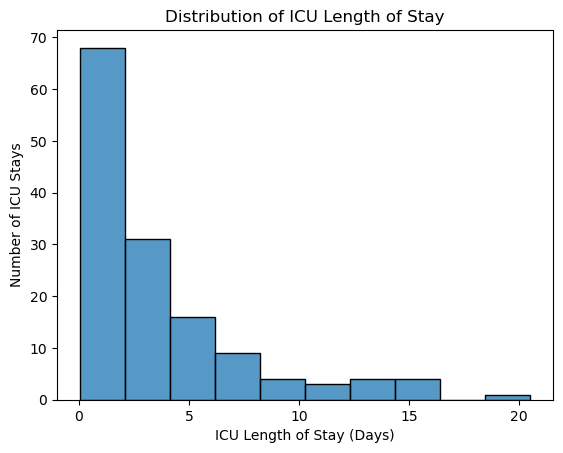

In [17]:
ax = sns.histplot(
    data=icu_stays,
    x='los',
    bins=10
)

plt.xlabel('ICU Length of Stay (Days)')
plt.ylabel('Number of ICU Stays')
plt.title('Distribution of ICU Length of Stay')

plt.savefig(
    FIGURES_DIR / 'icu_length_of_stay_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

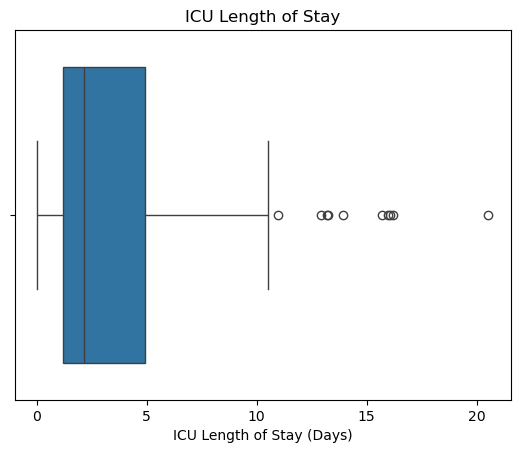

In [18]:
sns.boxplot(
    data=icu_stays,
    x='los'
)

plt.xlabel('ICU Length of Stay (Days)')
plt.title('ICU Length of Stay')

plt.show()

In [19]:
icu_stays["los"].describe()

count   140.00
mean      3.68
std       3.90
min       0.02
25%       1.17
50%       2.16
75%       4.91
max      20.53
Name: los, dtype: float64

# Admissions

The admissions table gives information regarding a patient’s admission to the hospital. Since each unique hospital visit for a patient is assigned a unique hadm_id, the admissions table can be considered as a definition table for hadm_id. Information available includes timing information for admission and discharge, demographic information, the source of the admission, and so on.

In [20]:
admissions = pd.read_csv(DATA_DIR/ "hosp"/"admissions.csv")

In [21]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [22]:
admissions.shape

(275, 16)

In [23]:
admissions.isna().sum()

subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
dtype: int64

In [24]:
admissions.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject_id,275.00,NaN,NaN,NaN,10018901.54,12127.77,10000032.00,10007873.00,10018081.00,10026255.00,10040025.00
hadm_id,275.00,NaN,NaN,NaN,25130546.59,2907533.43,20044587.00,22583130.00,25172300.00,27671548.00,29974575.00
admittime,275,275,2196-02-24 14:38:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dischtime,275,275,2196-03-04 14:02:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deathtime,15,15,2111-11-15 17:20:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type,275,9,EW EMER.,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admit_provider_id,275,170,P41R5N,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_location,275,10,EMERGENCY ROOM,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_location,233,10,HOME HEALTH CARE,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance,275,3,Other,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   subject_id            275 non-null    int64 
 1   hadm_id               275 non-null    int64 
 2   admittime             275 non-null    object
 3   dischtime             275 non-null    object
 4   deathtime             15 non-null     object
 5   admission_type        275 non-null    object
 6   admit_provider_id     275 non-null    object
 7   admission_location    275 non-null    object
 8   discharge_location    233 non-null    object
 9   insurance             275 non-null    object
 10  language              275 non-null    object
 11  marital_status        263 non-null    object
 12  race                  275 non-null    object
 13  edregtime             182 non-null    object
 14  edouttime             182 non-null    object
 15  hospital_expire_flag  275 non-null    in

In [26]:
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])

In [27]:
# Calculates hospital length of stay
admissions['hlos'] = (admissions['dischtime'] - admissions['admittime']).dt.total_seconds() / (24 * 60 * 60)

In [28]:
admissions.describe().T

,count,mean,min,25%,50%,75%,max,std
subject_id,275.00,10018901.54,10000032.00,10007873.00,10018081.00,10026255.00,10040025.00,12127.77
hadm_id,275.00,25130546.59,20044587.00,22583130.00,25172300.00,27671548.00,29974575.00,2907533.43
admittime,275,2153-06-09 16:25:00.654545920,2110-04-11 15:08:00,2136-11-02 13:59:00,2148-08-14 22:57:00,2176-11-20 07:45:00,2201-12-11 12:00:00,NaN
dischtime,275,2153-06-16 13:25:46.472727552,2110-04-14 15:00:00,2136-11-07 17:15:00,2148-08-18 21:12:00,2176-11-30 14:27:00,2201-12-17 13:45:00,NaN
hospital_expire_flag,275.00,0.05,0.00,0.00,0.00,0.00,1.00,0.23
hlos,275.00,6.88,0.05,2.69,4.85,8.77,44.93,6.73


### Hospital Mortality Distribution

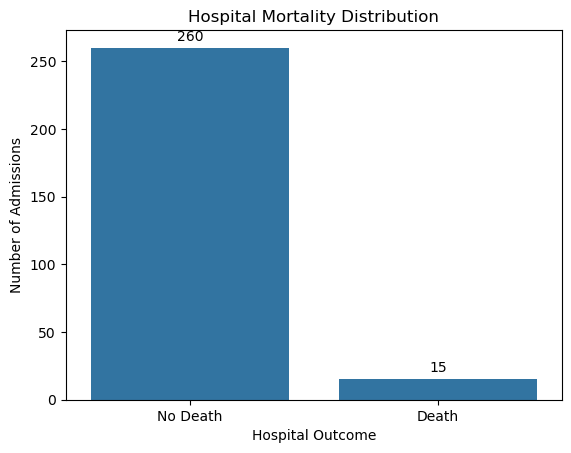

In [29]:
ax = sns.countplot(
    data=admissions,
    x='hospital_expire_flag'
)

plt.xlabel('Hospital Outcome')
plt.ylabel('Number of Admissions')
plt.title('Hospital Mortality Distribution')

plt.xticks([0, 1], ['No Death', 'Death'])

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.savefig(
    FIGURES_DIR / 'hosp_mortality_distribution.png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

In [30]:
# Patients who died during at least one hospitalization
in_hospital_deaths = (
    admissions.groupby("subject_id")["hospital_expire_flag"]
    .max()
)

in_hospital_deaths.value_counts()

hospital_expire_flag
0    85
1    15
Name: count, dtype: int64

In [31]:
death_admissions = admissions[admissions["hospital_expire_flag"] == 1]

print("Admissions ending in death:", len(death_admissions))
print("Unique patients:", death_admissions["subject_id"].nunique())

Admissions ending in death: 15
Unique patients: 15


In [32]:
print("Patients with recorded DOD:", patients["dod"].notna().sum())
print("Patients without recorded DOD:", patients["dod"].isna().sum())

Patients with recorded DOD: 31
Patients without recorded DOD: 69


In [33]:
# Patients with a recorded date of death
patients_with_dod = set(
    patients.loc[patients["dod"].notna(), "subject_id"]
)

# Patients who died during a hospital admission
in_hospital_deaths = set(
    admissions.loc[
        admissions["hospital_expire_flag"] == 1,
        "subject_id"
    ]
)

# Recorded DOD but no in-hospital death
other_recorded_deaths = patients_with_dod - in_hospital_deaths

print("Recorded DOD:", len(patients_with_dod))
print("In-hospital deaths:", len(in_hospital_deaths))
print("Recorded DOD without in-hospital death:", len(other_recorded_deaths))

Recorded DOD: 31
In-hospital deaths: 15
Recorded DOD without in-hospital death: 16


### Observation:

* Of the **100 patients**, **31 have a recorded date of death (`dod`)**, while **69 have no recorded date of death**.
* **15 patients** died during a hospital admission, as indicated by `hospital_expire_flag = 1`.
* An additional **16 patients have a recorded `dod` but no admission ending in an in-hospital death**.
* This confirms that `dod` and `hospital_expire_flag` represent different mortality information. The `hospital_expire_flag` will be used when analyzing **in-hospital mortality**, while `dod` provides broader patient-level mortality information.
* The 69 missing `dod` values will therefore **not be treated as conventional missing-data errors or imputed**.


### Hospital Length of Stay Distribution

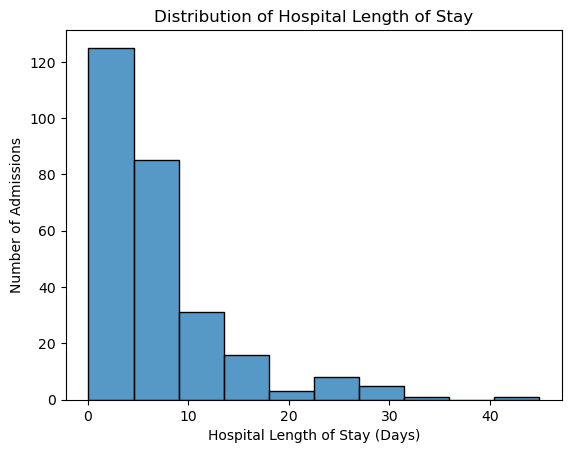

In [34]:
ax = sns.histplot(
    data=admissions,
    x='hlos',
    bins=10
)

plt.xlabel('Hospital Length of Stay (Days)')
plt.ylabel('Number of Admissions')
plt.title('Distribution of Hospital Length of Stay')

plt.show()

In [35]:
admissions["hlos"].describe()

count   275.00
mean      6.88
std       6.73
min       0.05
25%       2.69
50%       4.85
75%       8.77
max      44.93
Name: hlos, dtype: float64

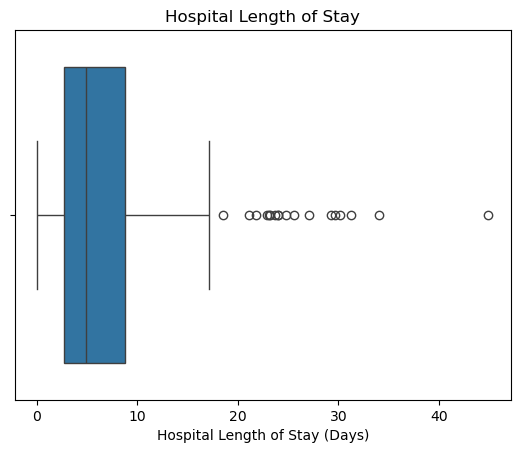

In [36]:
sns.boxplot(
    data=admissions,
    x='hlos'
)

plt.xlabel('Hospital Length of Stay (Days)')
plt.title('Hospital Length of Stay')


plt.show()

### Discharge Disposition

In [37]:
admissions["discharge_location"].value_counts()

discharge_location
HOME HEALTH CARE                76
HOME                            72
SKILLED NURSING FACILITY        36
DIED                            15
REHAB                           13
CHRONIC/LONG TERM ACUTE CARE     9
HOSPICE                          5
AGAINST ADVICE                   4
PSYCH FACILITY                   2
ACUTE HOSPITAL                   1
Name: count, dtype: int64

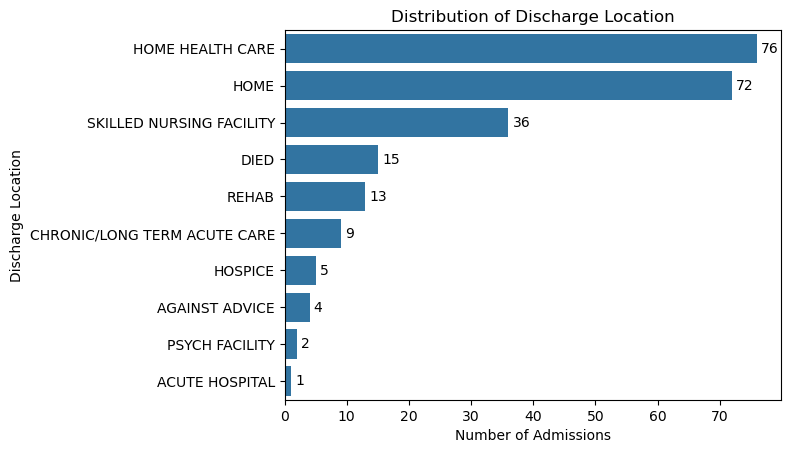

In [38]:
discharge_location_order = admissions['discharge_location'].value_counts().index

ax = sns.countplot(
    data=admissions,
    y='discharge_location',
    order=discharge_location_order
)

plt.ylabel('Discharge Location')
plt.xlabel('Number of Admissions')
plt.title('Distribution of Discharge Location')

# Add counts to the end of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.savefig(
    FIGURES_DIR / 'discharge_location_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Race Distribution

In [39]:
admissions.groupby('subject_id')['race'].nunique().value_counts()

race
1    96
2     4
Name: count, dtype: int64

In [40]:
race_per_patient = admissions.groupby('subject_id')['race'].nunique()

multiple_race_patients = race_per_patient[race_per_patient > 1].index

admissions[
    admissions['subject_id'].isin(multiple_race_patients)
][['subject_id', 'race']].drop_duplicates().sort_values('subject_id')

,subject_id,race
142,10004457,WHITE
273,10004457,OTHER
45,10035631,WHITE
46,10035631,UNKNOWN
107,10037928,HISPANIC/LATINO - CUBAN
186,10037928,HISPANIC OR LATINO
29,10038992,UNKNOWN
270,10038992,WHITE


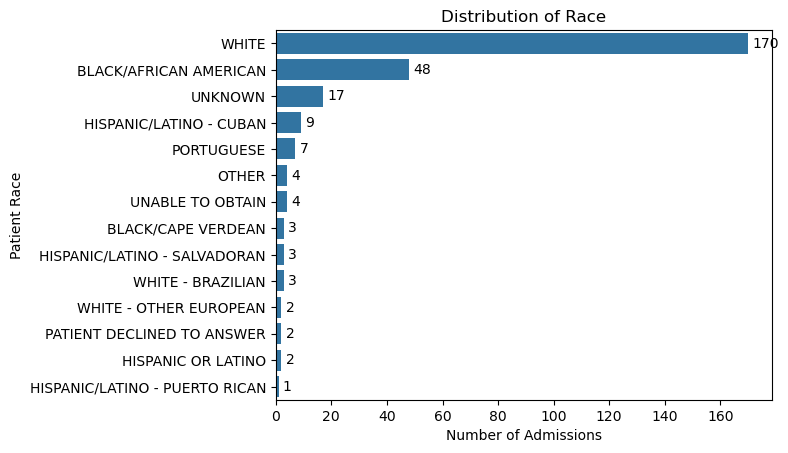

In [41]:
race_order = admissions['race'].value_counts().index

ax = sns.countplot(
    data=admissions,
    y='race',
    order=race_order
)

plt.ylabel('Patient Race')
plt.xlabel('Number of Admissions')
plt.title('Distribution of Race')

# Add counts to the end of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.savefig(
    FIGURES_DIR / 'patient_race_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Admission Type Distribution

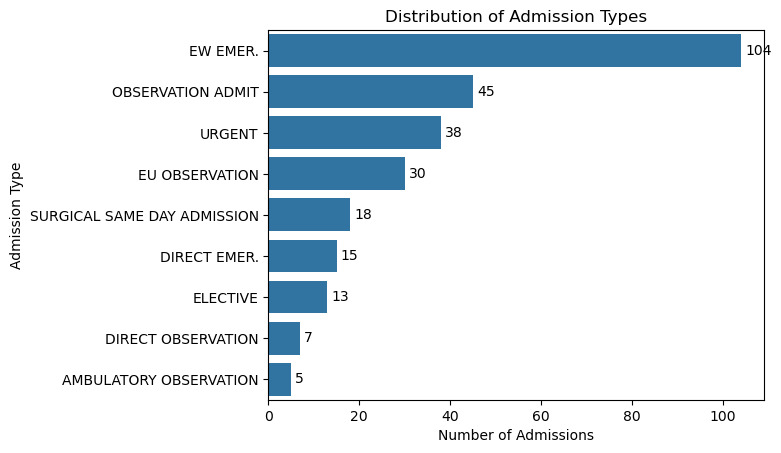

In [42]:
admission_type_order = admissions['admission_type'].value_counts().index

ax = sns.countplot(
    data=admissions,
    y='admission_type',
    order=admission_type_order
)

plt.ylabel('Admission Type')
plt.xlabel('Number of Admissions')
plt.title('Distribution of Admission Types')

# Add counts to the end of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.savefig(
    FIGURES_DIR / 'admission_type_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Diagnoses

### Deatiled Description

- `subject_id`
subject_id is a unique identifier which specifies an individual patient. Any rows associated with a single subject_id pertain to the same individual.

- `hadm_id`
hadm_id is an integer identifier which is unique for each patient hospitalization.

- `seq_num`
The priority assigned to the diagnoses. The priority can be interpreted as a ranking of which diagnoses are “important”, but many caveats to this broad statement exist. For example, patients who are diagnosed with sepsis must have sepsis as their 2nd billed condition. The 1st billed condition must be the infectious agent. There’s also less importance placed on ranking low priority diagnoses “correctly” (as there may be no correct ordering of the priority of the 5th - 10th diagnosis codes, for example).

- `icd_code, icd_version`
icd_code is the International Coding Definitions (ICD) code.

- There are two versions for this coding system: version 9 (ICD-9) and version 10 (ICD-10). These can be differentiated using the icd_version column. In general, ICD-10 codes are more detailed, though code mappings (or “cross-walks”) exist which convert ICD-9 codes to ICD-10 codes.

- Both ICD-9 and ICD-10 codes are often presented with a decimal. This decimal is not required for interpretation of an ICD code; i.e. the icd_code of ‘0010’ is equivalent to ‘001.0’.

In [43]:
diagnoses_icd = pd.read_csv(DATA_DIR /"hosp"/"diagnoses_icd.csv")

In [44]:
diagnoses_icd.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


In [45]:
diagnoses_icd.shape

(4506, 5)

In [46]:
diagnoses_icd.isna().sum()

subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64

In [47]:
diagnoses_icd.subject_id.nunique()

100

In [48]:
d_icd_diagnoses = pd.read_csv(DATA_DIR /"hosp"/"d_icd_diagnoses.csv")

In [49]:
d_icd_diagnoses.head()

,icd_code,icd_version,long_title
0,0090,9,"Infectious colitis, enteritis, and gastroenter..."
1,01160,9,"Tuberculous pneumonia [any form], unspecified"
2,01186,9,"Other specified pulmonary tuberculosis, tuberc..."
3,01200,9,"Tuberculous pleurisy, unspecified"
4,01236,9,"Tuberculous laryngitis, tubercle bacilli not f..."


In [50]:
d_icd_diagnoses.isna().sum()

icd_code       0
icd_version    0
long_title     0
dtype: int64

In [51]:
diagnoses = diagnoses_icd.merge(
    d_icd_diagnoses,
    on=['icd_code', 'icd_version'],
    how='left'
)

diagnoses.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10035185,22580999,3,4139,9,Other and unspecified angina pectoris
1,10035185,22580999,10,V707,9,Examination of participant in clinical trial
2,10035185,22580999,1,41401,9,Coronary atherosclerosis of native coronary ar...
3,10035185,22580999,9,3899,9,Unspecified hearing loss
4,10035185,22580999,11,V8532,9,"Body Mass Index 32.0-32.9, adult"


In [52]:
diagnoses.shape

(4506, 6)

In [53]:
diagnoses['long_title'].isna().sum()

np.int64(0)

### What are the most frequently recorded diagnoses?

In [54]:
diagnosis_counts = (
    diagnoses['long_title']
    .value_counts()
    .reset_index()
)

diagnosis_counts.columns = ['diagnosis', 'count']

diagnosis_counts.head(10)

,diagnosis,count
0,Unspecified essential hypertension,68
1,"Hyperlipidemia, unspecified",57
2,"Acute kidney failure, unspecified",56
3,Other and unspecified hyperlipidemia,55
4,"Hypothyroidism, unspecified",47
5,"Obesity, unspecified",43
6,"Anemia, unspecified",41
7,Long term (current) use of insulin,37
8,"Urinary tract infection, site not specified",36
9,Personal history of nicotine dependence,35


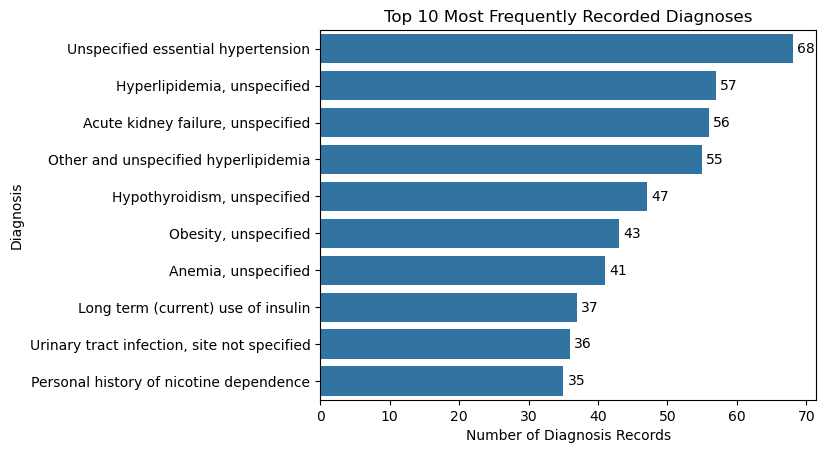

In [55]:
top_diagnoses = diagnoses['long_title'].value_counts().head(10)

ax = sns.barplot(
    x=top_diagnoses.values,
    y=top_diagnoses.index
)

plt.xlabel('Number of Diagnosis Records')
plt.ylabel('Diagnosis')
plt.title('Top 10 Most Frequently Recorded Diagnoses')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.savefig(
    FIGURES_DIR / 'top_10_diagnoses.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [56]:
unspecified = diagnoses[
    diagnoses['long_title'].str.contains(
        'unspecified',
        case=False,
        na=False
    )
]

print("Number of unspecified diagnosis records:", len(unspecified))
print(
    "Percentage:",
    round(len(unspecified) / len(diagnoses) * 100, 2),
    "%"
)

Number of unspecified diagnosis records: 1404
Percentage: 31.16 %


# Treatment and Care Patterns Analysis

### Prescriptions

In [57]:
prescriptions = pd.read_csv(DATA_DIR /"hosp"/"prescriptions.csv")

In [58]:
prescriptions.head()

,subject_id,hadm_id,pharmacy_id,poe_id,poe_seq,order_provider_id,starttime,stoptime,drug_type,drug,...,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
0,10027602,28166872,27168639,NaN,NaN,NaN,2201-10-30 12:00:00,NaN,MAIN,Fentanyl Citrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10027602,28166872,40720238,NaN,NaN,NaN,2201-10-30 12:00:00,NaN,MAIN,Fentanyl Citrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10027602,28166872,62845687,NaN,NaN,NaN,2201-10-31 12:00:00,NaN,MAIN,Lorazepam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10027602,28166872,24340150,NaN,NaN,NaN,2201-10-30 12:00:00,NaN,MAIN,Midazolam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10027602,28166872,14435820,NaN,NaN,NaN,2201-10-30 12:00:00,NaN,MAIN,Midazolam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
prescriptions.columns

Index(['subject_id', 'hadm_id', 'pharmacy_id', 'poe_id', 'poe_seq',
       'order_provider_id', 'starttime', 'stoptime', 'drug_type', 'drug',
       'formulary_drug_cd', 'gsn', 'ndc', 'prod_strength', 'form_rx',
       'dose_val_rx', 'dose_unit_rx', 'form_val_disp', 'form_unit_disp',
       'doses_per_24_hrs', 'route'],
      dtype='object')

In [60]:
prescriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18087 entries, 0 to 18086
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         18087 non-null  int64  
 1   hadm_id            18087 non-null  int64  
 2   pharmacy_id        18087 non-null  int64  
 3   poe_id             17969 non-null  object 
 4   poe_seq            17969 non-null  float64
 5   order_provider_id  17993 non-null  object 
 6   starttime          18087 non-null  object 
 7   stoptime           18073 non-null  object 
 8   drug_type          18087 non-null  object 
 9   drug               18087 non-null  object 
 10  formulary_drug_cd  18075 non-null  object 
 11  gsn                15568 non-null  object 
 12  ndc                18066 non-null  float64
 13  prod_strength      18078 non-null  object 
 14  form_rx            12 non-null     object 
 15  dose_val_rx        18078 non-null  object 
 16  dose_unit_rx       180

In [61]:
prescriptions.describe().T

,count,mean,std,min,25%,50%,75%,max
subject_id,18087.00,10019661.12,11860.13,10000032.00,10009049.00,10018501.00,10027602.00,10040025.00
hadm_id,18087.00,25201102.57,2944669.43,20044587.00,22675517.00,25129047.00,27984218.00,29974575.00
pharmacy_id,18087.00,50108259.04,28854297.01,1604.00,24989522.00,50063241.00,75296900.00,99998226.00
poe_seq,17969.00,587.93,609.92,3.00,149.00,351.00,846.00,3288.00
ndc,18066.00,17322727597.04,26488078116.86,0.00,121176130.00,409610210.00,50242004413.00,87701071218.00
doses_per_24_hrs,10704.00,1.53,1.04,0.00,1.00,1.00,2.00,12.00


In [62]:
prescriptions.shape

(18087, 21)

In [63]:
prescriptions.drug.value_counts().head()

drug
Insulin                        915
0.9% Sodium Chloride           810
Potassium Chloride             610
Sodium Chloride 0.9%  Flush    585
Furosemide                     510
Name: count, dtype: int64

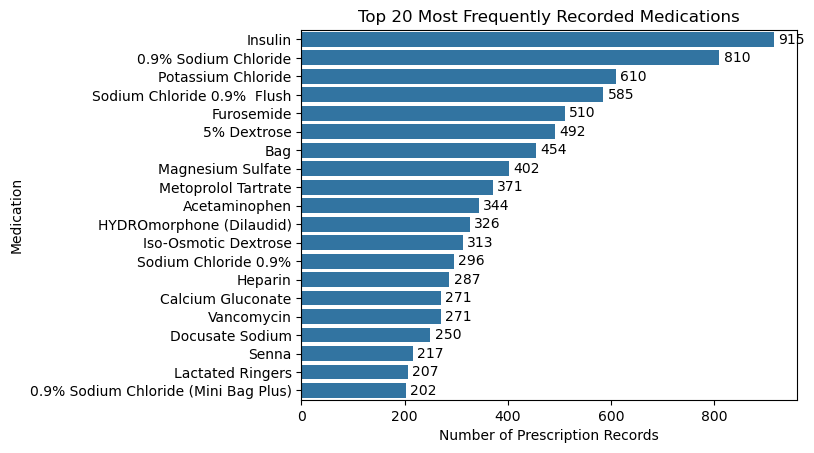

In [64]:
top_drugs = prescriptions['drug'].value_counts().head(20)

ax = sns.barplot(
    x=top_drugs.values,
    y=top_drugs.index
)

plt.xlabel('Number of Prescription Records')
plt.ylabel('Medication')
plt.title('Top 20 Most Frequently Recorded Medications')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


plt.show()

In [65]:
# Investigate the potentially overlapping sodium chloride entries
prescriptions[
    prescriptions['drug'].str.contains(
        'sodium chloride|bag',
        case=False,
        na=False
    )
]['drug'].value_counts()

drug
0.9% Sodium Chloride                    810
Sodium Chloride 0.9%  Flush             585
Bag                                     454
Sodium Chloride 0.9%                    296
0.9% Sodium Chloride (Mini Bag Plus)    202
Iso-Osmotic Sodium Chloride              60
5% Dextrose (EXCEL BAG)                  52
Syringe (0.9% Sodium Chloride)           46
0.45% Sodium Chloride                    21
Sodium Chloride Nasal                    14
0.83% Sodium Chloride                    12
Sodium Chloride                           3
0.9% NaCl (EXCEL/ViaFLO BAG)              2
Sodium Chloride 3% Inhalation Soln        1
Isotonic Sodium Chloride                  1
Sodium Chloride 3% (Hypertonic)           1
23.4% Sodium Chloride                     1
Name: count, dtype: int64

### Medication Utilization per Admission

In [66]:
medications_per_admission = (
    prescriptions
    .groupby('hadm_id')
    .size()
    .reset_index(name='prescription_count')
)

medication_utilization = (
    admissions[['hadm_id']]
    .drop_duplicates()
    .merge(
        medications_per_admission,
        on='hadm_id',
        how='left'
    )
)

medication_utilization['prescription_count'] = (
    medication_utilization['prescription_count'].fillna(0)
)

medication_utilization['prescription_count'].describe()

count   275.00
mean     65.77
std      60.95
min       0.00
25%      25.00
50%      48.00
75%      92.00
max     348.00
Name: prescription_count, dtype: float64

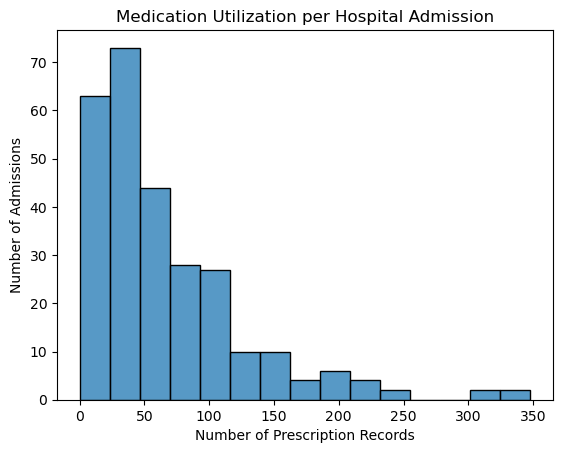

In [67]:
sns.histplot(
    data=medication_utilization,
    x='prescription_count',
    bins=15
)

plt.xlabel('Number of Prescription Records')
plt.ylabel('Number of Admissions')
plt.title('Medication Utilization per Hospital Admission')

plt.savefig(
    FIGURES_DIR / 'medication_utilization_per_admission.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [68]:
zero_prescriptions = (
    medication_utilization['prescription_count'] == 0
).sum()

zero_prescription_pct = (
    zero_prescriptions / len(medication_utilization) * 100
)

print(
    "Admissions with 0 prescription records:",
    zero_prescriptions
)

print(
    "Percentage:",
    round(zero_prescription_pct, 2),
    "%"
)

Admissions with 0 prescription records: 25
Percentage: 9.09 %


# Procedures

### procedures_icd Detailed Description
- `subject_id`
subject_id is a unique identifier which specifies an individual patient. Any rows associated with a single subject_id pertain to the same individual.

- `hadm_id`
hadm_id is an integer identifier which is unique for each patient hospitalization.

- `seq_num`
An assigned priority for procedures which occurred within the hospital stay.

- `chartdate`
The date of the associated procedures. Date does not strictly correlate with seq_num.

- `icd_code, icd_version`
icd_code is the International Coding Definitions (ICD) code.



In [69]:
procedures_icd = pd.read_csv(DATA_DIR/"hosp"/"procedures_icd.csv")

In [70]:
procedures_icd.head()

,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version
0,10011398,27505812,3,2146-12-15,3961,9
1,10011398,27505812,2,2146-12-15,3615,9
2,10011398,27505812,1,2146-12-15,3614,9
3,10014729,23300884,4,2125-03-23,3897,9
4,10014729,23300884,1,2125-03-20,3403,9


In [71]:
procedures_icd.shape

(722, 6)

In [72]:
procedures_icd.isna().sum()

subject_id     0
hadm_id        0
seq_num        0
chartdate      0
icd_code       0
icd_version    0
dtype: int64

In [73]:
procedures_icd.seq_num.value_counts()

seq_num
1     187
2     136
3     101
4      72
5      49
6      40
7      29
8      24
9      18
10     13
12      7
11      7
13      6
14      5
15      5
16      4
18      3
19      3
17      3
20      3
21      3
23      2
22      2
Name: count, dtype: int64

In [74]:
d_icd_procedures = pd.read_csv(DATA_DIR /"hosp"/"d_icd_procedures.csv")

In [75]:
d_icd_procedures.head()

,icd_code,icd_version,long_title
0,0039,9,Other computer assisted surgery
1,0048,9,Insertion of four or more vascular stents
2,0074,9,"Hip bearing surface, metal-on-polyethylene"
3,0077,9,"Hip bearing surface, ceramic-on-polyethylene"
4,0126,9,Insertion of catheter(s) into cranial cavity o...


In [76]:
# Merge the procedures information
procedures = procedures_icd.merge(
    d_icd_procedures,
    on=['icd_code', 'icd_version'],
    how='left'
)

In [77]:
procedures.head()

,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version,long_title
0,10011398,27505812,3,2146-12-15,3961,9,Extracorporeal circulation auxiliary to open h...
1,10011398,27505812,2,2146-12-15,3615,9,Single internal mammary-coronary artery bypass
2,10011398,27505812,1,2146-12-15,3614,9,(Aorto)coronary bypass of four or more coronar...
3,10014729,23300884,4,2125-03-23,3897,9,Central venous catheter placement with guidance
4,10014729,23300884,1,2125-03-20,3403,9,Reopening of recent thoracotomy site


In [78]:
procedures['long_title'].isna().sum()

np.int64(0)

In [79]:
procedures.shape

(722, 7)

In [80]:
procedure_counts = (
    procedures['long_title']
    .value_counts()
    .reset_index()
)

procedure_counts.columns = ['Procedure', 'Count']

procedure_counts.head(20)

,Procedure,Count
0,Insertion of Infusion Device into Superior Ven...,23
1,Central venous catheter placement with guidance,22
2,Enteral infusion of concentrated nutritional s...,18
3,Continuous invasive mechanical ventilation for...,15
4,Extracorporeal circulation auxiliary to open h...,13
5,"Venous catheterization, not elsewhere classified",13
6,Percutaneous abdominal drainage,12
7,Insertion of endotracheal tube,11
8,"Insertion of Endotracheal Airway into Trachea,...",10
9,Introduction of Nutritional Substance into Upp...,10


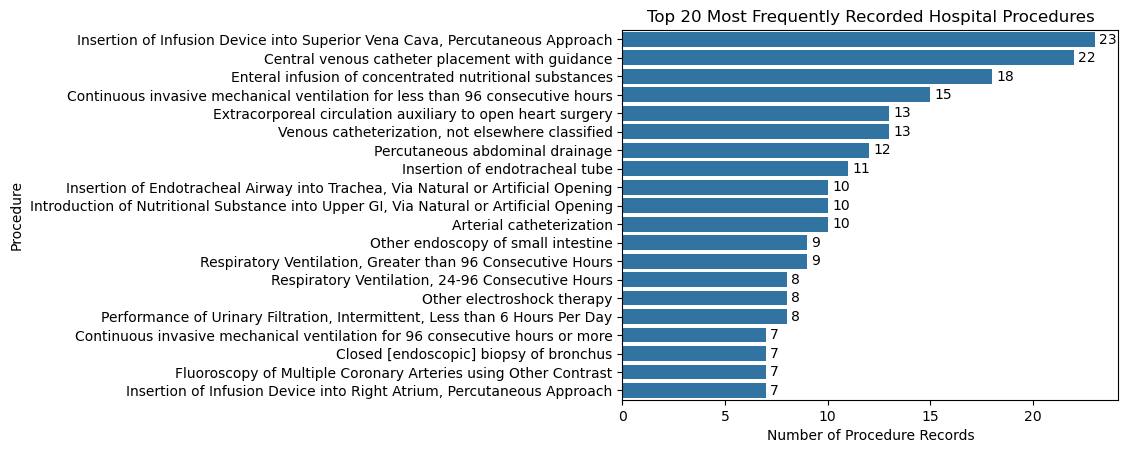

In [81]:
top_20_procedures = procedure_counts.head(20)

ax = sns.barplot(
    data=top_20_procedures,
    x='Count',
    y='Procedure'
)

plt.xlabel('Number of Procedure Records')
plt.ylabel('Procedure')
plt.title('Top 20 Most Frequently Recorded Hospital Procedures')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


plt.show()

### Procedure Utilization

In [82]:
procedures_per_admission = (
    procedures_icd
    .groupby('hadm_id')
    .size()
    .reset_index(name='procedure_count')
)

procedures_per_admission['procedure_count'].describe()

count   187.00
mean      3.86
std       3.72
min       1.00
25%       1.00
50%       3.00
75%       5.00
max      23.00
Name: procedure_count, dtype: float64

In [83]:
procedure_utilization = (
    admissions[['hadm_id']]
    .drop_duplicates()
    .merge(
        procedures_per_admission,
        on='hadm_id',
        how='left'
    )
)

procedure_utilization['procedure_count'] = (
    procedure_utilization['procedure_count'].fillna(0)
)

procedure_utilization['procedure_count'].describe()

count   275.00
mean      2.63
std       3.56
min       0.00
25%       0.00
50%       1.00
75%       4.00
max      23.00
Name: procedure_count, dtype: float64

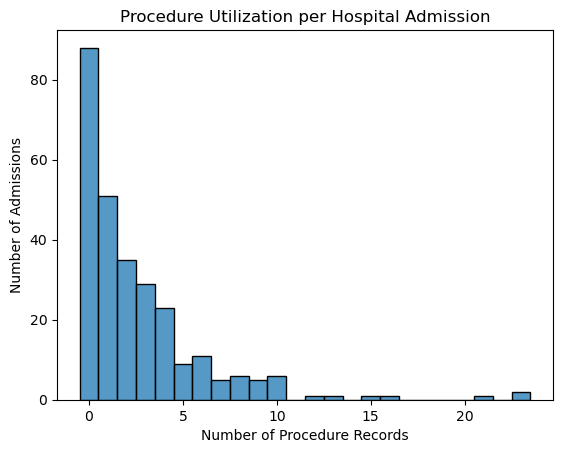

In [84]:
sns.histplot(
    data=procedure_utilization,
    x='procedure_count',
    discrete=True
)

plt.xlabel('Number of Procedure Records')
plt.ylabel('Number of Admissions')
plt.title('Procedure Utilization per Hospital Admission')


plt.show()

In [85]:
zero_procedures = (
    procedure_utilization['procedure_count'] == 0
).sum()

zero_procedure_pct = (
    zero_procedures / len(procedure_utilization) * 100
)

print("Admissions with 0 procedure records:", zero_procedures)
print("Percentage:", round(zero_procedure_pct, 2), "%")

Admissions with 0 procedure records: 88
Percentage: 32.0 %


## Procedures/interventions occurring during ICU stays

In [86]:
procedureevents =  pd.read_csv(DATA_DIR/"icu"/"procedureevents.csv")

In [87]:
procedureevents.head()

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,value,valueuom,...,orderid,linkorderid,ordercategoryname,ordercategorydescription,patientweight,isopenbag,continueinnextdept,statusdescription,ORIGINALAMOUNT,ORIGINALRATE
0,10027445,26275841,34499716,10712.00,2142-07-31 01:54:00,2142-08-02 10:44:00,2142-08-02 10:44:00,225792,3410.00,min,...,532221,532221,Ventilation,ContinuousProcess,103.00,1,0,FinishedRunning,3410.00,1
1,10027445,26275841,34499716,80518.00,2142-07-31 08:18:00,2142-08-03 15:10:00,2142-08-03 15:23:00,224263,4732.00,min,...,401769,401769,Invasive Lines,ContinuousProcess,103.00,1,0,FinishedRunning,4732.00,1
2,10027445,26275841,34499716,96407.00,2142-07-31 06:00:00,2142-08-03 06:03:00,2142-08-03 08:16:00,224275,4323.00,min,...,9714245,9714245,Peripheral Lines,ContinuousProcess,103.00,1,0,FinishedRunning,4323.00,1
3,10027445,26275841,34499716,96407.00,2142-07-31 02:00:00,2142-08-03 05:57:00,2142-08-03 08:15:00,224275,4557.00,min,...,2870557,2870557,Peripheral Lines,ContinuousProcess,103.00,1,0,FinishedRunning,4557.00,1
4,10027445,26275841,34499716,NaN,2142-08-03 08:00:00,2142-08-03 21:06:00,2142-08-03 21:06:00.090,224277,786.00,min,...,4920092,4920092,Peripheral Lines,ContinuousProcess,103.00,1,0,FinishedRunning,786.00,1


In [88]:
procedureevents.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'starttime',
       'endtime', 'storetime', 'itemid', 'value', 'valueuom', 'location',
       'locationcategory', 'orderid', 'linkorderid', 'ordercategoryname',
       'ordercategorydescription', 'patientweight', 'isopenbag',
       'continueinnextdept', 'statusdescription', 'ORIGINALAMOUNT',
       'ORIGINALRATE'],
      dtype='object')

In [89]:
procedureevents.shape

(1468, 22)

In [90]:
d_items = pd.read_csv(DATA_DIR/"icu"/"d_items.csv")


In [91]:
d_items.head()

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,226228,Gender,Gender,chartevents,ADT,NaN,Text,NaN,NaN
1,226545,Race,Race,chartevents,ADT,NaN,Text,NaN,NaN
2,229877,Suction events (CH),Suction events (CH),chartevents,ECMO,NaN,Text,NaN,NaN
3,229875,Oxygenator visible (CH),Oxygenator visible (CH),chartevents,ECMO,NaN,Text,NaN,NaN
4,229266,Cannula sites visually inspected (ECMO),Cannula sites visually inspected (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN


In [92]:
icu_procedures = procedureevents.merge(
    d_items[['itemid', 'label', 'category']],
    on='itemid',
    how='left'
)

In [93]:
icu_procedures.head()

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,value,valueuom,...,ordercategoryname,ordercategorydescription,patientweight,isopenbag,continueinnextdept,statusdescription,ORIGINALAMOUNT,ORIGINALRATE,label,category
0,10027445,26275841,34499716,10712.00,2142-07-31 01:54:00,2142-08-02 10:44:00,2142-08-02 10:44:00,225792,3410.00,min,...,Ventilation,ContinuousProcess,103.00,1,0,FinishedRunning,3410.00,1,Invasive Ventilation,2-Ventilation
1,10027445,26275841,34499716,80518.00,2142-07-31 08:18:00,2142-08-03 15:10:00,2142-08-03 15:23:00,224263,4732.00,min,...,Invasive Lines,ContinuousProcess,103.00,1,0,FinishedRunning,4732.00,1,Multi Lumen,Access Lines - Invasive
2,10027445,26275841,34499716,96407.00,2142-07-31 06:00:00,2142-08-03 06:03:00,2142-08-03 08:16:00,224275,4323.00,min,...,Peripheral Lines,ContinuousProcess,103.00,1,0,FinishedRunning,4323.00,1,20 Gauge,Access Lines - Peripheral
3,10027445,26275841,34499716,96407.00,2142-07-31 02:00:00,2142-08-03 05:57:00,2142-08-03 08:15:00,224275,4557.00,min,...,Peripheral Lines,ContinuousProcess,103.00,1,0,FinishedRunning,4557.00,1,20 Gauge,Access Lines - Peripheral
4,10027445,26275841,34499716,NaN,2142-08-03 08:00:00,2142-08-03 21:06:00,2142-08-03 21:06:00.090,224277,786.00,min,...,Peripheral Lines,ContinuousProcess,103.00,1,0,FinishedRunning,786.00,1,18 Gauge,Access Lines - Peripheral


In [94]:
icu_procedures['label'].isna().sum()

np.int64(0)

In [95]:
icu_procedure_counts = (
    icu_procedures['label']
    .value_counts()
    .head(15)
    .reset_index()
)

icu_procedure_counts.columns = ['Intervention', 'Count']

icu_procedure_counts

,Intervention,Count
0,20 Gauge,174
1,Chest X-Ray,171
2,18 Gauge,109
3,Arterial Line,82
4,EKG,69
5,Invasive Ventilation,65
6,CT scan,58
7,Extubation,49
8,Multi Lumen,45
9,Family updated by RN,43


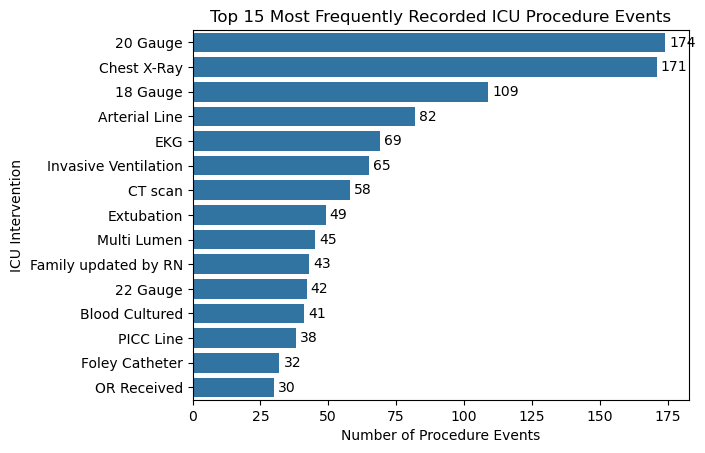

In [96]:
ax = sns.barplot(
    data=icu_procedure_counts,
    x='Count',
    y='Intervention'
)

plt.xlabel('Number of Procedure Events')
plt.ylabel('ICU Intervention')
plt.title('Top 15 Most Frequently Recorded ICU Procedure Events')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

In [97]:
inputevents =  pd.read_csv(DATA_DIR/"icu"/"inputevents.csv")

In [98]:
inputevents.head()

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,amount,amountuom,...,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
0,10005817,20626031,32604416,4793,2132-12-16 19:50:00,2132-12-16 19:51:00,2132-12-16 19:50:00,225798,1.00,dose,...,Main order parameter,Drug Push,91.00,500.00,ml,0,0,FinishedRunning,1.00,1.00
1,10005817,20626031,32604416,92805,2132-12-15 20:15:00,2132-12-15 20:16:00,2132-12-15 20:11:00,225798,1.00,dose,...,Main order parameter,Drug Push,91.00,500.00,ml,0,0,FinishedRunning,1.00,1.00
2,10005817,20626031,32604416,20310,2132-12-17 09:15:00,2132-12-17 09:16:00,2132-12-17 09:28:00,225798,1.00,dose,...,Main order parameter,Drug Push,91.00,500.00,ml,0,0,FinishedRunning,1.00,1.00
3,10005817,20626031,32604416,79166,2132-12-16 09:36:00,2132-12-16 09:37:00,2132-12-16 09:37:00,225798,1.00,dose,...,Main order parameter,Drug Push,91.00,500.00,ml,0,0,FinishedRunning,1.00,1.00
4,10005817,20626031,32604416,92805,2132-12-15 20:10:00,2132-12-15 21:10:00,2132-12-15 20:10:00,221456,2.00,grams,...,Additives ...,Continuous IV,91.00,100.00,ml,0,0,FinishedRunning,2.00,0.03


In [99]:
inputevents.shape

(20404, 26)

In [100]:
icu_inputs = inputevents.merge(
    d_items[['itemid', 'label', 'category']],
    on='itemid',
    how='left'
)

In [101]:
input_counts = (
    icu_inputs['label']
    .value_counts()
    .head(15)
    .reset_index()
)

input_counts.columns = ['Input', 'Count']

input_counts

,Input,Count
0,NaCl 0.9%,2870
1,Dextrose 5%,2358
2,Solution,1287
3,Norepinephrine,947
4,PO Intake,805
5,Propofol,794
6,Gastric Meds,668
7,Phenylephrine,625
8,GT Flush,581
9,Fentanyl,575


In [102]:
outputevents =  pd.read_csv(DATA_DIR/"icu"/"outputevents.csv")

In [103]:
outputevents.shape

(9362, 9)

In [104]:
icu_outputs = outputevents.merge(
    d_items[['itemid', 'label', 'category']],
    on='itemid',
    how='left'
)

In [105]:
icu_outputs.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valueuom,label,category
0,10002428,23473524,35479615,29441,2156-05-15 18:00:00,2156-05-15 17:42:00,226583,600,ml,Rectal Tube,Output
1,10002428,23473524,35479615,29441,2156-05-15 12:00:00,2156-05-15 12:08:00,226559,60,ml,Foley,Output
2,10002428,23473524,35479615,29441,2156-05-15 13:00:00,2156-05-15 13:00:00,226559,45,ml,Foley,Output
3,10002428,23473524,35479615,29441,2156-05-15 08:00:00,2156-05-15 08:39:00,226559,125,ml,Foley,Output
4,10002428,23473524,35479615,29441,2156-05-15 14:00:00,2156-05-15 13:56:00,226559,60,ml,Foley,Output


In [106]:
output_counts = (
    icu_outputs['label']
    .value_counts()
    .head(10)
    .reset_index()
)

output_counts.columns = ['Output', 'Count']

output_counts

,Output,Count
0,Foley,6685
1,Chest Tube #1,641
2,Void,496
3,TF Residual,325
4,Cerebral Ventricular #1,223
5,Jackson Pratt #1,121
6,Ostomy (output),92
7,Condom Cath,90
8,Oral Gastric,66
9,Jackson Pratt #2,57


# Transfers

Physical locations for patients throughout their hospital stay.

`Links to`
- patients on subject_id
- admissions on hadm_id

* **`eventtype`**: Describes the type of location event recorded for the patient:

  * `ed` – Emergency department stay
  * `admit` – Admission to the hospital
  * `transfer` – Movement between locations within the hospital
  * `discharge` – Discharge from the hospital

> **Note:** Despite its name, the `transfers` table represents patients’ **physical locations throughout their hospital stay**, rather than only transfer events. A `transfer` is just one of the event types recorded in the table and specifically refers to an **intra-hospital movement**.


In [107]:
transfers =  pd.read_csv(DATA_DIR/"hosp"/"transfers.csv")

In [108]:
transfers.head()

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
0,10009049,22995465.00,30030230,discharge,NaN,2174-05-31 14:21:47,NaN
1,10025612,23403708.00,32533329,discharge,NaN,2125-10-03 12:25:27,NaN
2,10020786,23488445.00,37922399,discharge,NaN,2189-06-13 17:25:44,NaN
3,10014078,25809882.00,34694622,discharge,NaN,2166-08-26 14:49:42,NaN
4,10039831,26924951.00,37155928,discharge,NaN,2116-01-02 14:35:02,NaN


In [109]:
transfers.isna().sum()

subject_id       0
hadm_id         54
transfer_id      0
eventtype        0
careunit       275
intime           0
outtime        275
dtype: int64

In [110]:
transfers.shape

(1190, 7)

In [111]:
transfers.eventtype.value_counts()

eventtype
transfer     404
discharge    275
admit        275
ED           236
Name: count, dtype: int64

### Observation:

* There are **275 `admit` events**, which is consistent with the **275 admission records** in the `admissions` table.
* `transfer` is the most frequent event type, with **404 records**, reflecting movements between hospital locations during a patient's stay.
* There are also **275 `discharge` events** and **236 `ED` events**.


In [112]:
transfers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subject_id   1190 non-null   int64  
 1   hadm_id      1136 non-null   float64
 2   transfer_id  1190 non-null   int64  
 3   eventtype    1190 non-null   object 
 4   careunit     915 non-null    object 
 5   intime       1190 non-null   object 
 6   outtime      915 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 65.2+ KB


In [113]:
transfers_per_admission = (
    transfers[
        transfers['eventtype'] == 'transfer'
    ]
    .dropna(subset=['hadm_id'])
    .groupby('hadm_id')
    .size()
    .reset_index(name='transfer_count')
)

In [114]:
transfer_utilization = (
    admissions[['hadm_id']]
    .drop_duplicates()
    .merge(
        transfers_per_admission,
        on='hadm_id',
        how='left'
    )
)

transfer_utilization['transfer_count'] = (
    transfer_utilization['transfer_count']
    .fillna(0)
    .astype(int)
)

transfer_utilization['transfer_count'].describe()

count   275.00
mean      1.47
std       1.60
min       0.00
25%       0.00
50%       1.00
75%       2.00
max       8.00
Name: transfer_count, dtype: float64

In [115]:
# calculate how many admissions had no transfer events
zero_transfers = (
    transfer_utilization['transfer_count'] == 0
).sum()

zero_transfer_pct = (
    zero_transfers /
    len(transfer_utilization) * 100
)

print("Admissions with 0 transfer events:", zero_transfers)
print("Percentage:", round(zero_transfer_pct, 2), "%")

Admissions with 0 transfer events: 100
Percentage: 36.36 %


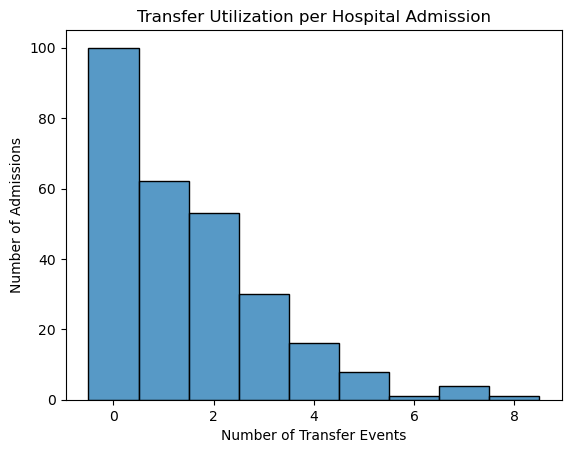

In [116]:
sns.histplot(
    data=transfer_utilization,
    x='transfer_count',
    discrete=True
)

plt.xlabel('Number of Transfer Events')
plt.ylabel('Number of Admissions')
plt.title('Transfer Utilization per Hospital Admission')


plt.show()

# Resource-Utilization Summary

In [117]:
resource_utilization = (
    admissions[
        ['subject_id', 'hadm_id', 'hlos']
    ]
    .merge(
        procedures_per_admission,
        on='hadm_id',
        how='left'
    )
    .merge(
        medications_per_admission,
        on='hadm_id',
        how='left'
    )
    .merge(
        transfers_per_admission,
        on='hadm_id',
        how='left'
    )
)

resource_utilization[
    ['procedure_count',
     'prescription_count',
     'transfer_count']
] = (
    resource_utilization[
        ['procedure_count',
         'prescription_count',
         'transfer_count']
    ].fillna(0)
)

resource_utilization.head()

,subject_id,hadm_id,hlos,procedure_count,prescription_count,transfer_count
0,10004235,24181354,8.97,5.00,195.00,2.00
1,10009628,25926192,7.84,3.00,166.00,2.00
2,10018081,23983182,5.73,2.00,59.00,0.00
3,10006053,22942076,1.74,3.00,63.00,2.00
4,10031404,21606243,2.09,1.00,34.00,1.00


In [118]:
resource_utilization[
    [
        'hlos',
        'procedure_count',
        'prescription_count',
        'transfer_count'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
hlos,275.00,6.88,6.73,0.05,2.69,4.85,8.77,44.93
procedure_count,275.00,2.63,3.56,0.00,0.00,1.00,4.00,23.00
prescription_count,275.00,65.77,60.95,0.00,25.00,48.00,92.00,348.00
transfer_count,275.00,1.47,1.60,0.00,0.00,1.00,2.00,8.00


# Combining Patients->Admissions->ICUstays

In [119]:
patient_admissions = admissions.merge(
    patients,
    on="subject_id",
    how="left"
)

print(patient_admissions.shape)
patient_admissions.head()

(275, 22)


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,race,edregtime,edouttime,hospital_expire_flag,hlos,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,...,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0,8.97,M,47,2196,2014 - 2016,NaN
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,...,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0,7.84,M,58,2153,2011 - 2013,NaN
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0,5.73,M,79,2133,2011 - 2013,2134-10-28
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,...,UNKNOWN,NaN,NaN,1,1.74,M,52,2111,2014 - 2016,2111-11-15
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,...,WHITE,NaN,NaN,0,2.09,F,82,2113,2014 - 2016,NaN


In [120]:
patient_admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            275 non-null    int64         
 1   hadm_id               275 non-null    int64         
 2   admittime             275 non-null    datetime64[ns]
 3   dischtime             275 non-null    datetime64[ns]
 4   deathtime             15 non-null     object        
 5   admission_type        275 non-null    object        
 6   admit_provider_id     275 non-null    object        
 7   admission_location    275 non-null    object        
 8   discharge_location    233 non-null    object        
 9   insurance             275 non-null    object        
 10  language              275 non-null    object        
 11  marital_status        263 non-null    object        
 12  race                  275 non-null    object        
 13  edregtime           

In [121]:
patient_admissions.isna().sum()

subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
hlos                      0
gender                    0
anchor_age                0
anchor_year               0
anchor_year_group         0
dod                     172
dtype: int64

### How many admissions did each patient have?

In [122]:
admission_counts = (
    admissions.groupby("subject_id")["hadm_id"]
    .nunique()
    .reset_index(name="number_of_admissions")
)

admission_counts["multiple_admissions"] = (
    admission_counts["number_of_admissions"] > 1
)

admission_counts["multiple_admissions"].value_counts()

multiple_admissions
False    52
True     48
Name: count, dtype: int64

In [123]:
admission_counts["number_of_admissions"].value_counts().sort_index()

number_of_admissions
1     52
2     20
3      9
4      2
5      2
6      3
7      4
8      1
9      1
10     3
12     1
13     1
20     1
Name: count, dtype: int64

In [124]:
single_admissions = admission_counts.loc[
    admission_counts["number_of_admissions"] == 1,
    "number_of_admissions"
].sum()

repeat_admissions = admission_counts.loc[
    admission_counts["number_of_admissions"] > 1,
    "number_of_admissions"
].sum()

print("Admissions from single-admission patients:", single_admissions)
print("Admissions from repeat-admission patients:", repeat_admissions)

Admissions from single-admission patients: 52
Admissions from repeat-admission patients: 223


### Observation:

* Among the **100 unique patients**, **52 (52%) had one hospital admission**, while **48 (48%) had multiple admissions**.
* The number of admissions per patient ranged from **1 to 20**, indicating substantial variation in hospital utilization.
* Although fewer than half of the patients had repeat admissions, their admissions account for a large proportion of the **275 total hospital admissions**.
* A small number of patients had particularly high numbers of admissions, suggesting the presence of **high-utilization patients** that may warrant further investigation.


### Do patients with multiple hospital admissions differ from single-admission patients in their characteristics, ICU utilization, and outcomes?

In [125]:
# 1. Summarize hospital admissions by patient
admission_summary = (
    admissions.groupby("subject_id")
    .agg(
        number_of_admissions=("hadm_id", "nunique"),
        ever_died_in_hospital=("hospital_expire_flag", "max")
    )
    .reset_index()
)

admission_summary["multiple_admissions"] = (
    admission_summary["number_of_admissions"] > 1
)


# 2. Summarize ICU utilization by patient
icu_summary = (
    icu_stays.groupby("subject_id")
    .agg(
        number_of_icu_stays=("stay_id", "nunique")
    )
    .reset_index()
)

icu_summary["ever_admitted_to_icu"] = True


# 3. Start with patient characteristics
patient_summary = patients[
    ["subject_id", "gender", "anchor_age"]
].copy()


# 4. Add hospital admission information
patient_summary = patient_summary.merge(
    admission_summary,
    on="subject_id",
    how="left"
)


# 5. Add ICU information
patient_summary = patient_summary.merge(
    icu_summary,
    on="subject_id",
    how="left"
)


# 6. Patients without an ICU record did not have an ICU stay
patient_summary["ever_admitted_to_icu"] = (
    patient_summary["ever_admitted_to_icu"]
    .fillna(False)
    .astype(bool)
)

patient_summary["number_of_icu_stays"] = (
    patient_summary["number_of_icu_stays"]
    .fillna(0)
    .astype(int)
)


# 7. Arrange columns
patient_summary = patient_summary[
    [
        "subject_id",
        "gender",
        "anchor_age",
        "number_of_admissions",
        "multiple_admissions",
        "ever_admitted_to_icu",
        "number_of_icu_stays",
        "ever_died_in_hospital"
    ]
]

patient_summary.head()

,subject_id,gender,anchor_age,number_of_admissions,multiple_admissions,ever_admitted_to_icu,number_of_icu_stays,ever_died_in_hospital
0,10014729,F,21,2,True,True,1,0
1,10003400,F,72,7,True,True,3,1
2,10002428,F,80,7,True,True,4,0
3,10032725,F,38,2,True,True,1,0
4,10027445,F,48,3,True,True,2,0


In [126]:
print("Rows:", len(patient_summary))
print("Unique patients:", patient_summary["subject_id"].nunique())

print("\nMultiple admissions:")
print(patient_summary["multiple_admissions"].value_counts())

print("\nEver admitted to ICU:")
print(patient_summary["ever_admitted_to_icu"].value_counts())

print("\nNumber of ICU stays:")
print(patient_summary["number_of_icu_stays"].value_counts().sort_index())

print("\nEver died in hospital:")
print(patient_summary["ever_died_in_hospital"].value_counts())

Rows: 100
Unique patients: 100

Multiple admissions:
multiple_admissions
False    52
True     48
Name: count, dtype: int64

Ever admitted to ICU:
ever_admitted_to_icu
True    100
Name: count, dtype: int64

Number of ICU stays:
number_of_icu_stays
1    74
2    16
3     7
4     2
5     1
Name: count, dtype: int64

Ever died in hospital:
ever_died_in_hospital
0    85
1    15
Name: count, dtype: int64


### Observation:

* The patient-level dataset contains **100 unique patients**, with one record per patient.
* **48 patients (48%)** had multiple hospital admissions, while **52 (52%)** had only one admission.
* All **100 patients had at least one ICU stay**, indicating that the available sample represents an ICU patient population rather than a mixture of ICU and non-ICU patients.
* Most patients (**74%**) had one ICU stay, while **26%** had multiple ICU stays. The number of ICU stays ranged from **1 to 5 per patient**.
* **15 patients (15%)** experienced an in-hospital death.

Because all patients in the sample had an ICU stay, comparisons between ICU and non-ICU patients cannot be performed using this dataset. Subsequent analysis will instead examine variation in **ICU utilization and outcomes within the ICU patient population**, including differences by patient characteristics, repeat hospital admissions, number of ICU stays, length of stay, and in-hospital mortality.


In [127]:
patient_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   subject_id             100 non-null    int64 
 1   gender                 100 non-null    object
 2   anchor_age             100 non-null    int64 
 3   number_of_admissions   100 non-null    int64 
 4   multiple_admissions    100 non-null    bool  
 5   ever_admitted_to_icu   100 non-null    bool  
 6   number_of_icu_stays    100 non-null    int64 
 7   ever_died_in_hospital  100 non-null    int64 
dtypes: bool(2), int64(5), object(1)
memory usage: 5.0+ KB


In [128]:
patient_summary.drop(columns="subject_id").describe().T

,count,mean,std,min,25%,50%,75%,max
anchor_age,100.00,61.75,16.17,21.00,51.75,63.00,72.00,91.00
number_of_admissions,100.00,2.75,3.18,1.00,1.00,1.00,3.00,20.00
number_of_icu_stays,100.00,1.40,0.79,1.00,1.00,1.00,2.00,5.00
ever_died_in_hospital,100.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00


### Patient-Level Analysis

The patient-level analysis examines whether patient characteristics are associated with patterns of hospital and ICU utilization. Since all patients in the available sample experienced at least one ICU stay, the analysis focuses on differences **within the ICU patient population**.

The following questions will be explored:

1. **Are age and gender associated with repeat hospital admissions?**
2. **Are patients with multiple hospital admissions more likely to have multiple ICU stays?**
3. **Do patient characteristics differ between patients with one ICU stay and those with multiple ICU stays?**


In [129]:
patient_summary["multiple_icu_stays"] = (
    patient_summary["number_of_icu_stays"] > 1
)

patient_summary["multiple_icu_stays"].value_counts()

multiple_icu_stays
False    74
True     26
Name: count, dtype: int64

### Are age and gender associated with repeat hospital admissions?

In [130]:
patient_summary.groupby("multiple_admissions")["anchor_age"].describe().T

multiple_admissions,False,True
count,52.00,48.00
mean,62.50,60.94
std,16.44,16.00
min,26.00,21.00
25%,51.75,51.00
50%,63.00,63.00
75%,73.50,71.25
max,91.00,91.00


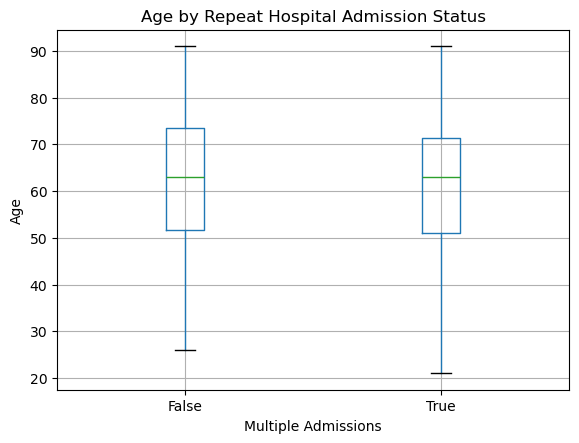

In [131]:
patient_summary.boxplot(
    column="anchor_age",
    by="multiple_admissions"
)

plt.title("Age by Repeat Hospital Admission Status")
plt.suptitle("")
plt.xlabel("Multiple Admissions")
plt.ylabel("Age")
plt.show()

### Observation:

* Patients with a **single hospital admission** had a mean age of **62.5 years**, compared with **60.9 years** among patients with multiple admissions.
* The **median age was 63 years in both groups**.
* The age distributions were also similar in terms of variability and quartiles.
* Overall, there is **little descriptive difference in age** between patients with single and multiple hospital admissions in this sample.
* A statistical test will be conducted to determine whether the observed difference in age is statistically significant.


In [132]:
pd.crosstab(
    patient_summary["gender"],
    patient_summary["multiple_admissions"],
    margins=True
)

multiple_admissions,False,True,All
gender,,,
F,18,25,43
M,34,23,57
All,52,48,100


In [133]:
pd.crosstab(
    patient_summary["gender"],
    patient_summary["multiple_admissions"],
    normalize="index"
).round(3) * 100

multiple_admissions,False,True
gender,,
F,41.90,58.10
M,59.60,40.40


### Observation:

* Among **female patients**, **58.1% had multiple hospital admissions**, while **41.9% had a single admission**.
* Among **male patients**, **40.4% had multiple hospital admissions**, while **59.6% had a single admission**.
* Descriptively, repeat hospital admissions were more common among female patients than male patients in this sample.
* A statistical significance test is needed to determine whether the observed difference in repeat admission status by gender is statistically significant.


### Are patients with multiple hospital admissions more likely to have multiple ICU stays?

In [134]:
pd.crosstab(
    patient_summary["multiple_admissions"],
    patient_summary["multiple_icu_stays"],
    margins=True
)

multiple_icu_stays,False,True,All
multiple_admissions,,,
False,49,3,52
True,25,23,48
All,74,26,100


In [135]:
pd.crosstab(
    patient_summary["multiple_admissions"],
    patient_summary["multiple_icu_stays"],
    normalize="index"
).round(3) * 100

multiple_icu_stays,False,True
multiple_admissions,,
False,94.20,5.80
True,52.10,47.90


### Observation:

* Among patients with a **single hospital admission**, **94.2% had only one ICU stay**, while **5.8% had multiple ICU stays**.
* Among patients with **multiple hospital admissions**, **52.1% had one ICU stay** and **47.9% had multiple ICU stays**.
* Descriptively, patients with repeat hospital admissions were substantially more likely to have multiple ICU stays than patients with only one hospital admission.
* A statistical significance test will be conducted to determine whether the observed relationship between repeat hospital admissions and multiple ICU stays is statistically significant.


### Do patient characteristics differ between patients with one ICU stay and those with multiple ICU stays?

In [136]:
patient_summary.groupby("multiple_icu_stays")["anchor_age"].describe().T

multiple_icu_stays,False,True
count,74.00,26.00
mean,61.91,61.31
std,16.98,13.90
min,21.00,29.00
25%,51.25,52.25
50%,63.00,61.50
75%,73.50,70.00
max,91.00,87.00


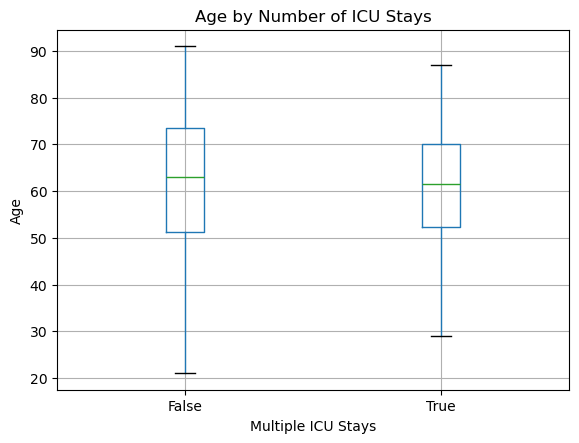

In [137]:
patient_summary.boxplot(
    column="anchor_age",
    by="multiple_icu_stays"
)

plt.title("Age by Number of ICU Stays")
plt.suptitle("")
plt.xlabel("Multiple ICU Stays")
plt.ylabel("Age")
plt.show()

### Observation:

* Patients with **one ICU stay** had a mean age of **61.9 years**, compared with **61.3 years** among patients with multiple ICU stays.
* Median age was also similar between the groups (**63.0 vs. 61.5 years**).
* The age distributions showed comparable variability and overlapping quartiles.
* Overall, there is **little descriptive difference in age** between patients with one ICU stay and those with multiple ICU stays in this sample.
* A statistical test will be used to determine whether the observed difference in age is statistically significant.


### What percentage of female patients had multiple ICU stays compared with male patients?

In [138]:
pd.crosstab(
    patient_summary["gender"],
    patient_summary["multiple_icu_stays"],
    margins=True
)

multiple_icu_stays,False,True,All
gender,,,
F,29,14,43
M,45,12,57
All,74,26,100


In [139]:
pd.crosstab(
    patient_summary["gender"],
    patient_summary["multiple_icu_stays"],
    normalize="index"
).round(3) * 100

multiple_icu_stays,False,True
gender,,
F,67.40,32.60
M,78.90,21.10


### Observation:

* Among **female patients**, **32.6% had multiple ICU stays**, while **67.4% had one ICU stay**.
* Among **male patients**, **21.1% had multiple ICU stays**, while **78.9% had one ICU stay**.
* Descriptively, multiple ICU stays were more common among female patients than male patients in this sample.
* A statistical significance test is needed to determine whether the observed relationship between gender and ICU stay frequency is statistically significant.
